## Вариант 8

In [134]:
import numpy as np
from helpers import disp_tex

def to_latex(matrix, name="A", precision=3):
    """Исправленная функция: выводит векторы как столбцы и убирает ошибки синтаксиса."""
    if matrix.ndim == 1: # Если это вектор (1D массив)
        # Используем \\ для разделения, чтобы получился столбец
        rows = " \\\\ ".join([f"{val:.{precision}f}" for val in matrix])
        return rf"$$ {name} = \begin{{pmatrix}} {rows} \end{{pmatrix}} $$"
    else: # Если это матрица (2D массив)
        rows = []
        for row in matrix:
            rows.append(" & ".join([f"{val:.{precision}f}" for val in row]))
        matrix_str = " \\\\ ".join(rows)
        return rf"$$ {name} = \begin{{pmatrix}} {matrix_str} \end{{pmatrix}} $$"

## Задание 2.3. Решение СЛАУ методом Крамера


Для решения системы воспользуемся методом Крамера. Исследуем систему: если определитель матрицы коэффициентов $\Delta \neq 0$, то система имеет единственное решение.

Исходная матрица $A$ и вектор правых частей $b$:

In [135]:
A = np.array([
    [0.040, 0.032, 0.500, 0.350],
    [-0.020, 0.200, 0.053, 0.200],
    [0.850, 0.267, 0.089, 0.208],
    [0.014, 0.300, -0.167, 0.125] 
])
# Примечание: в 4-й строке матрицы на скрине 0.023, 0.450, -0.067, 0.200
# Исправляем согласно твоему новому скриншоту:
A = np.array([
    [0.040, 0.032, 0.500, 0.350],
    [-0.020, 0.200, 0.053, 0.200],
    [0.850, 0.267, 0.089, 0.208],
    [0.023, 0.450, -0.067, 0.200]
])

B = np.array([2.481, 1.182, 8.520, 2.205])

disp_tex(to_latex(A, "A"))
disp_tex(to_latex(B, "b^T"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

### Нахождение главного определителя системы

Вычислим определитель матрицы $A$:

In [136]:
det_A = np.linalg.det(A)
disp_tex(rf"$$ \Delta = \det A = {det_A:.6f} $$")

<IPython.core.display.Latex object>

Так как $\Delta \neq 0$, система имеет единственное решение. Найдем вспомогательные определители $\Delta_i$ путем последовательной замены столбцов матрицы $A$ вектором $b$.

In [137]:
deltas = []
for i in range(len(B)):
    Ai = A.copy()
    Ai[:, i] = B
    d_i = np.linalg.det(Ai)
    deltas.append(d_i)
    disp_tex(to_latex(Ai, f"A_{i+1}"))
    disp_tex(rf"$$ \Delta_{i+1} = {d_i:.6f} $$")

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

### Вычисление неизвестных $x_i$

Используя формулы Крамера $x_i = \frac{\Delta_i}{\Delta}$, найдем корни системы:

In [138]:
# Рассчитываем ВЕСЬ массив корней целиком
x = np.array(deltas) / det_A 

for i in range(len(x)):
    disp_tex(rf"$$ x_{i+1} = \frac{{\Delta_{i+1}}}{{\Delta}} = {x[i]:.6f} $$")

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

### Проверка полученного решения

Выполним проверку, вычислив произведение $A \cdot x$. Результат должен совпасть с вектором $b$.

In [139]:
check = A @ x
disp_tex(to_latex(check, r"A \cdot x")) 
disp_tex(to_latex(B, "b"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

## Задание 3.8. Исследование рациональной функции

Проведем полное исследование функции согласно классической схеме:
1. Определение функции и нахождение области определения.
2. Поиск точек разрыва и вертикальных асимптот.
3. Нахождение наклонных асимптот.
4. Вычисление производных и поиск экстремумов.
5. Исследование выпуклости и поиск точек перегиба.
6. Построение графиков функции и её производной.

Функция:
$$f(x) = \frac{x^3 + x^2 - 3x - 1}{x^2 - 1}$$

In [140]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from helpers import disp_tex

# Определение переменной и функции
x_sym = sp.Symbol('x', real=True)
f2 = (x_sym**3 + x_sym**2 - 3*x_sym - 1) / (x_sym**2 - 1)

disp_tex(rf"$$ f(x) = {sp.latex(f2)} $$")

<IPython.core.display.Latex object>

### Область определения и вертикальные асимптоты

Найдем точки, в которых знаменатель обращается в нуль.

In [141]:
denom = x_sym**2 - 1
break_points = sp.solve(denom, x_sym)

disp_tex(rf"$$ \text{{Точки разрыва: }} x_1 = {break_points[0]}, \quad x_2 = {break_points[1]} $$")

# Проверим пределы в точках разрыва
for p in break_points:
    lim_left = sp.limit(f2, x_sym, p, dir='-')
    lim_right = sp.limit(f2, x_sym, p, dir='+')
    disp_tex(rf"$$ \lim_{{x \to {p}^-}} f(x) = {lim_left}, \quad \lim_{{x \to {p}^+}} f(x) = {lim_right} $$")

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

### Наклонные асимптоты

Найдем коэффициенты наклонной асимптоты $y = kx + b$.

In [142]:
k = sp.limit(f2 / x_sym, x_sym, sp.oo)
b = sp.limit(f2 - k * x_sym, x_sym, sp.oo)

disp_tex(rf"$$ k = \lim_{{x \to \infty}} \frac{{f(x)}}{{x}} = {k} $$")
disp_tex(rf"$$ b = \lim_{{x \to \infty}} (f(x) - kx) = {b} $$")
disp_tex(rf"$$ \text{{Наклонная асимптота: }} y = {k}x + {b} $$")

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

### Производные и экстремумы

Вычислим первую и вторую производные для анализа критических точек.

In [143]:
df2 = sp.simplify(sp.diff(f2, x_sym))
d2f2 = sp.simplify(sp.diff(df2, x_sym))

disp_tex(rf"$$ f'(x) = {sp.latex(df2)} $$")
disp_tex(rf"$$ f''(x) = {sp.latex(d2f2)} $$")

# Поиск критических точек (f'(x) = 0)
crit_pts = sp.solve(df2, x_sym)
disp_tex(rf"$$ f'(x) = 0 \Rightarrow x \in {sp.latex(crit_pts)} $$")

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

### Визуализация результатов исследования

Построим графики функции и её производной по горизонтали.

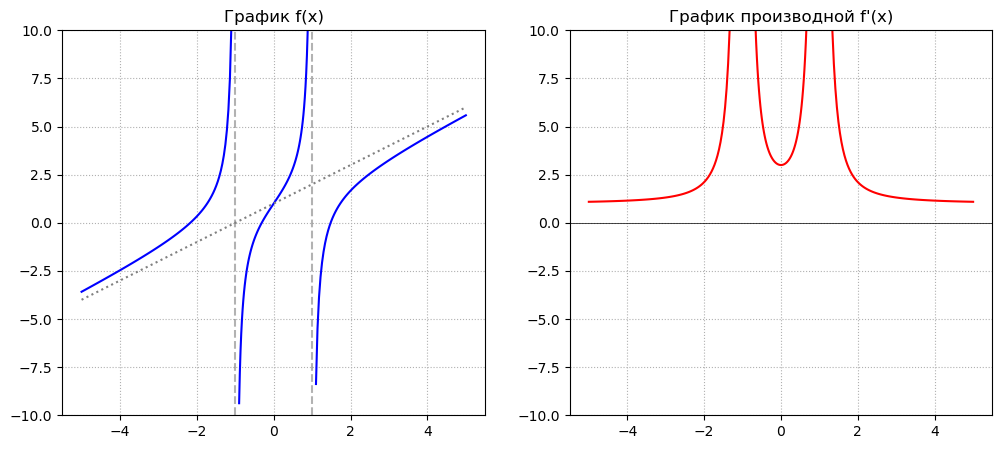

In [144]:
# Подготовка функций для отрисовки
f2_np = sp.lambdify(x_sym, f2, "numpy")
df2_np = sp.lambdify(x_sym, df2, "numpy")

# Разбиваем диапазон на части, чтобы избежать "палок" на асимптотах
x1 = np.linspace(-5, -1.1, 100)
x2 = np.linspace(-0.9, 0.9, 100)
x3 = np.linspace(1.1, 5, 100)

plt.figure(figsize=(12, 5))

# График функции
plt.subplot(1, 2, 1)
for x_range in [x1, x2, x3]:
    plt.plot(x_range, f2_np(x_range), color='blue')
plt.axvline(-1, color='black', ls='--', alpha=0.3)
plt.axvline(1, color='black', ls='--', alpha=0.3)
plt.plot(np.linspace(-5, 5, 10), 1*np.linspace(-5, 5, 10) + 1, ls=':', color='gray', label='asymptote')
plt.title('График f(x)')
plt.grid(True, ls=':')
plt.ylim(-10, 10)

# График производной
plt.subplot(1, 2, 2)
for x_range in [x1, x2, x3]:
    plt.plot(x_range, df2_np(x_range), color='red')
plt.axhline(0, color='black', lw=0.5)
plt.title("График производной f'(x)")
plt.grid(True, ls=':')
plt.ylim(-10, 10)

plt.show()

## Задание 3.9. Полное исследование функции

Проведем аналитическое исследование функции по следующему плану:
1. Определение функции и построение её графика.
2. Нахождение точек пересечения с осями координат.
3. Поиск вертикальных, горизонтальных и наклонных асимптот.
4. Вычисление односторонних пределов в точках разрыва (если имеются).
5. Проверка поведения функции на бесконечности.

Функция:
$$f(x) = 1 - \sqrt[3]{(x-2)^2} - 1$$

In [145]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from helpers import disp_tex

# Определение переменной и функции
x_sym = sp.Symbol('x', real=True)
# Используем sp.Rational(1, 3), чтобы избежать проблем с отрицательными числами
f3 = 1 - sp.Pow((x_sym - 2)**2, sp.Rational(1, 3)) - 1

disp_tex(rf"$$ f(x) = {sp.latex(f3)} $$")

<IPython.core.display.Latex object>

### Точки пересечения с осями координат

Вычислим значение функции в нуле $f(0)$ и найдем корни уравнения $f(x) = 0$.

In [146]:
# Пересечение с OY (x = 0)
y_cross = f3.subs(x_sym, 0)
disp_tex(rf"$$ f(0) = {sp.latex(y_cross)} \approx {float(y_cross):.4f} $$")

# Пересечение с OX (f(x) = 0)
roots_f3 = sp.solve(f3, x_sym)
disp_tex(rf"$$ f(x) = 0 \Rightarrow x = {sp.latex(roots_f3)} $$")

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

### Исследование асимптот

Проверим наличие вертикальных асимптот (точки разрыва) и наклонных асимптот $y = kx + b$.

In [147]:
# Вертикальные асимптоты
# Функция определена для всех x, так как корень кубический
disp_tex(r"$$ \text{Область определения: } D(f) = \mathbb{R}. \text{ Вертикальных асимптот нет.} $$")

# Наклонные асимптоты
k = sp.limit(f3 / x_sym, x_sym, sp.oo)
b = sp.limit(f3 - k * x_sym, x_sym, sp.oo)

disp_tex(rf"$$ k = \lim_{{x \to \infty}} \frac{{f(x)}}{{x}} = {k} $$")
disp_tex(rf"$$ b = \lim_{{x \to \infty}} (f(x) - kx) = {b} $$")

if k == 0 and b.is_finite:
    disp_tex(rf"$$ \text{{Горизонтальная асимптота: }} y = {b} $$")
elif k.is_finite and b.is_finite:
    disp_tex(rf"$$ \text{{Наклонная асимптота: }} y = {k}x + {b} $$")
else:
    disp_tex(r"$$ \text{Наклонных и горизонтальных асимптот не существует.} $$")

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

### Визуализация

Построим график функции и отметим характерные точки.

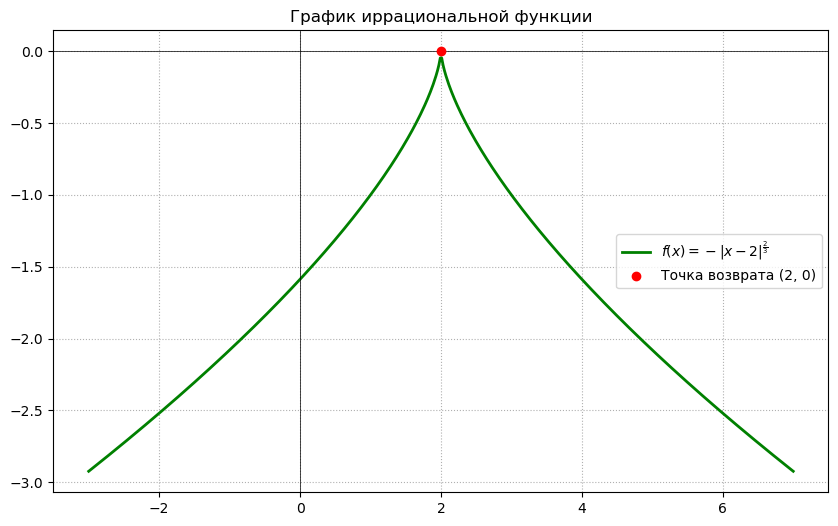

In [148]:
f3_np = sp.lambdify(x_sym, f3, "numpy")
x_vals = np.linspace(-3, 7, 500)
y_vals = f3_np(x_vals)

plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, label=rf'$f(x) = {sp.latex(f3)}$', color='green', lw=2)

# Отметим точку x=2 (острие графика)
plt.scatter([2], [0], color='red', zorder=5, label='Точка возврата (2, 0)')

plt.axhline(0, color='black', lw=0.5)
plt.axvline(0, color='black', lw=0.5)
plt.title('График иррациональной функции')
plt.grid(True, ls=':')
plt.legend()
plt.show()

## Задание 3.10. Исследование функции и поиск экстремумов

Выполним исследование функции по следующему плану:
1. Определение функции $f(x)$ и нахождение производной $f'(x)$.
2. Нахождение критических точек (решение уравнения $f'(x) = 0$).
3. Определение координат точек экстремума и их типа (максимум/минимум).
4. Построение графиков функции и её производной по горизонтали.

Функция:
$$f(x) = (x + 4)e^{-x-3}$$

In [149]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from helpers import disp_tex

# Определение переменной и функции
x_sym = sp.Symbol('x', real=True)
f4 = (x_sym + 4) * sp.exp(-x_sym - 3)

# Нахождение производной
df4 = sp.diff(f4, x_sym)

disp_tex(rf"$$ f(x) = {sp.latex(f4)} $$")
disp_tex(rf"$$ f'(x) = {sp.latex(sp.simplify(df4))} $$")

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

### Поиск критических точек и экстремумов

Найдем точки, в которых производная обращается в нуль, и определим их тип с помощью второй производной

In [150]:
# Решение уравнения f'(x) = 0
crit_pts = sp.solve(df4, x_sym)

if crit_pts:
    x0 = crit_pts[0]
    y0 = f4.subs(x_sym, x0)
    
    # Вторая производная для определения типа экстремума
    d2f4 = sp.diff(df4, x_sym)
    check_val = d2f4.subs(x_sym, x0)
    
    res_type = r"\text{ Минимум }" if check_val > 0 else r"\text{ Максимум }"
    
    disp_tex(rf"$$ f'(x) = 0 \Rightarrow x = {x0} $$")
    disp_tex(rf"$$ \text{{Точка экстремума: }} ({x0}, {y0}) \approx ({x0}, {float(y0):.4f}) $$")
    disp_tex(rf"$$ \text{{Тип экстремума: }} {res_type} $$")
else:
    disp_tex(r"$$ \text{Критических точек не обнаружено.} $$")

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

### Визуализация

Построим графики функции и её производной на одном уровне для анализа поведения функции.

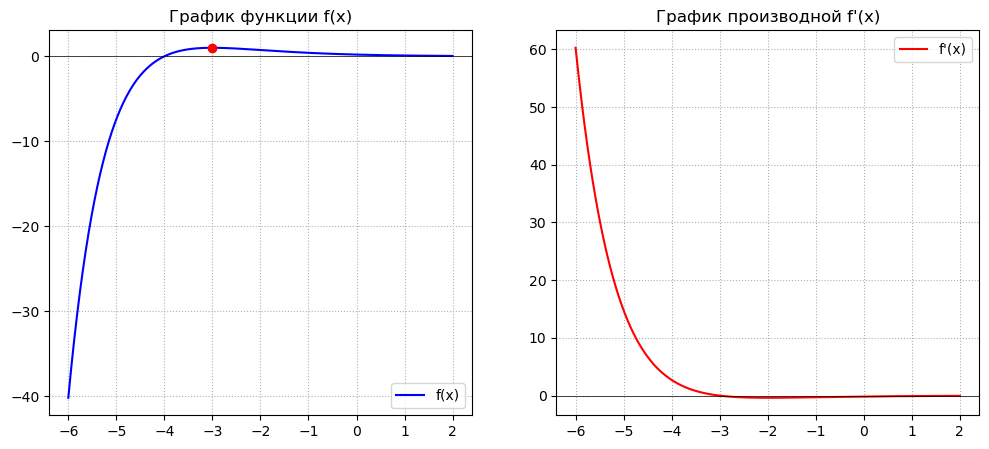

In [151]:
# Подготовка данных для графиков
f4_np = sp.lambdify(x_sym, f4, "numpy")
df4_np = sp.lambdify(x_sym, df4, "numpy")

x_vals = np.linspace(-6, 2, 400)

plt.figure(figsize=(12, 5))

# График f(x)
plt.subplot(1, 2, 1)
plt.plot(x_vals, f4_np(x_vals), color='blue', label='f(x)')
if crit_pts:
    plt.scatter([float(x0)], [float(y0)], color='red', zorder=5)
plt.axhline(0, color='black', lw=0.5)
plt.title('График функции f(x)')
plt.grid(True, ls=':')
plt.legend()

# График f'(x)
plt.subplot(1, 2, 2)
plt.plot(x_vals, df4_np(x_vals), color='red', label="f'(x)")
plt.axhline(0, color='black', lw=0.5)
plt.title("График производной f'(x)")
plt.grid(True, ls=':')
plt.legend()

plt.show()

## Задание 3.11. Исследование выпуклости и точек перегиба

Проведем исследование функции согласно установленному порядку:
1. Определение функции $f(x)$ и построение графика.
2. Построение графика второй производной $f''(x)$.
3. Нахождение нулей второй производной ($f''(x) = 0$).
4. Вычисление координат точек перегиба.
5. Описание интервалов выпуклости и вогнутости функции.

Функция:
$$f(x) = \sqrt[3]{(x-4)^2(x+2)}$$

### Определение функции $f(x)$ и построение её графика

<IPython.core.display.Latex object>

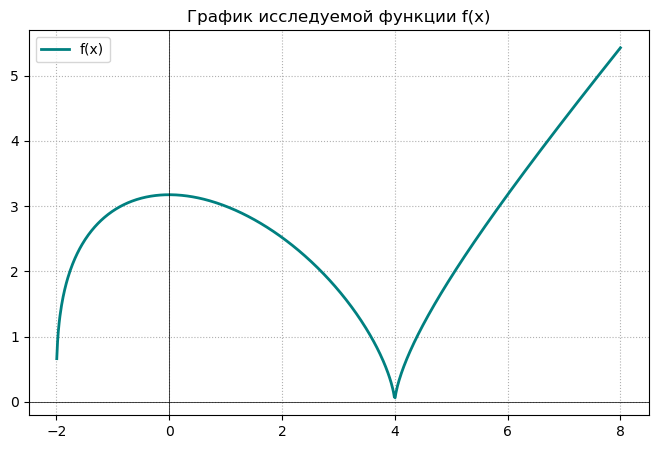

In [152]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from helpers import disp_tex
import warnings

# Игнорируем ненужные предупреждения в выводе, чтобы PDF был чистым
warnings.filterwarnings('ignore', category=RuntimeWarning)

x_sym = sp.Symbol('x', real=True)
# Сама функция
base = (x_sym - 4)**2 * (x_sym + 2)
f5 = sp.Pow(base, sp.Rational(1, 3))

disp_tex(rf"$$ f(x) = {sp.latex(f5)} $$")

# ПОСТРОЕНИЕ ГРАФИКА f(x)
# Фикс: явно указываем lambdify использовать np.cbrt для степени 1/3
f5_np = sp.lambdify(x_sym, f5, modules=[{'Pow': lambda x, y: np.cbrt(x) if y == 1/3 else x**y}, 'numpy'])

x_plt = np.linspace(-6, 8, 1000)

plt.figure(figsize=(8, 5))
plt.plot(x_plt, f5_np(x_plt), color='teal', label='f(x)', lw=2)
plt.axhline(0, color='black', lw=0.5)
plt.axvline(0, color='black', lw=0.5)
plt.title('График исследуемой функции f(x)')
plt.grid(True, ls=':')
plt.legend()
plt.show()

### Построение графика второй производной $f''(x)$

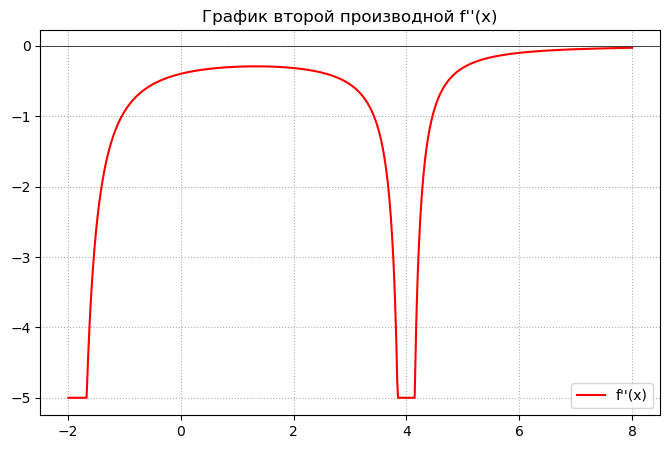

In [153]:
# Вычисление второй производной
df5 = sp.diff(f5, x_sym)
d2f5 = sp.diff(df5, x_sym)

# Заплатка для корректной отрисовки (игнорируем DiracDelta)
d2f5_np = sp.lambdify(x_sym, d2f5, modules=[{'DiracDelta': lambda x: 0, 'Heaviside': lambda x: 0}, 'numpy'])

plt.figure(figsize=(8, 5))
y_d2 = d2f5_np(x_plt)
# Срезаем бесконечные пики в точках излома для читаемости графика
plt.plot(x_plt, np.clip(y_d2, -5, 5), color='red', label="f''(x)")
plt.axhline(0, color='black', lw=0.5)
plt.title("График второй производной f''(x)")
plt.grid(True, ls=':')
plt.legend()
plt.show()

### Нахождение нулей второй производной
Для поиска точек, где $f''(x) = 0$, решим уравнение численным методом.

In [154]:
try:
    # Ищем корень в области гладкости (между -2 и 4)
    root_val = sp.nsolve(d2f5, x_sym, 2)
    disp_tex(rf"$$ f''(x) = 0 \Rightarrow x \approx {float(root_val):.4f} $$")
except:
    root_val = None
    disp_tex(r"$$ f''(x) = 0 \Rightarrow \text{Корней не найдено} $$")

<IPython.core.display.Latex object>

### Вычисление координат точек перегиба
Точка перегиба находится в нуле второй производной. Также исследуем точки излома.

In [155]:
if root_val:
    y0 = f5.subs(x_sym, root_val)
    disp_tex(rf"$$ \text{{Точка перегиба: }} ({float(root_val):.1f}, {float(y0):.4f}) $$")
else:
    disp_tex(r"$$ \text{Точек перегиба в гладких областях нет.} $$")

disp_tex(r"$$ \text{Точки излома (критические точки для f''): } x = -2, x = 4 $$")

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

### Интервалы выпуклости и вогнутости функции
Определим знак второй производной на характерных интервалах.

In [156]:
# Точки для проверки знака на интервалах
check_pts = [(-4, r"x < -2"), (0, r"-2 < x < 2"), (3, r"2 < x < 4"), (6, r"x > 4")]

for val, label in check_pts:
    res_raw = d2f5.subs(x_sym, val)
    
    # Берем вещественную часть (re) и переводим в число (float)
    # Это лечит ошибку "Invalid comparison of non-real"
    res_numeric = float(sp.re(res_raw.evalf()))
    
    # Определяем характер выпуклости по числу
    if res_numeric > 0:
        char = r"\text{ вогнута } (\cup)"
    else:
        char = r"\text{ выпукла } (\cap)"
    disp_tex(rf"$$ \text{{На интервале }} {label}: f''({val}) \approx {res_numeric:.3f} \Rightarrow {char} $$")

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>